In [407]:
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import random

In [408]:
data = genfromtxt("advertising.csv", delimiter=',', skip_header=1)
N = data.shape[0]
X = data[:, :3]
y = data[:, 3:]
print(X[:5])
print(y[:5])

[[230.1  37.8  69.2]
 [ 44.5  39.3  45.1]
 [ 17.2  45.9  69.3]
 [151.5  41.3  58.5]
 [180.8  10.8  58.4]]
[[22.1]
 [10.4]
 [12. ]
 [16.5]
 [17.9]]


In [409]:
def mean_normalization(X):
    N = len(X)
    maxi = np.max(X)
    mini = np.min(X)
    avg = np.mean(X)
    X = (X - avg) / (maxi - mini)
    X_b = np.c_[np.ones((N, 1)), X]
    return X_b, maxi, mini, avg

X_b, maxi, mini, avg = mean_normalization(X)
print(X_b)

[[ 1.00000000e+00  5.50426788e-01 -9.83586370e-02  7.57928475e-03]
 [ 1.00000000e+00 -7.57540486e-02 -9.32979082e-02 -7.37297571e-02]
 [ 1.00000000e+00 -1.67859312e-01 -7.10307018e-02  7.91666667e-03]
 [ 1.00000000e+00  2.85244602e-01 -8.65502699e-02 -2.85205803e-02]
 [ 1.00000000e+00  3.84097503e-01 -1.89451754e-01 -2.88579622e-02]
 [ 1.00000000e+00 -1.96536775e-01 -6.09092443e-02  2.71474359e-02]
 [ 1.00000000e+00 -3.18943995e-02 -1.15227733e-01 -1.46604251e-01]
 [ 1.00000000e+00  1.79644062e-01 -1.59762146e-01 -1.86752699e-01]
 [ 1.00000000e+00 -1.96874157e-01 -2.18803981e-01 -2.22515182e-01]
 [ 1.00000000e+00  4.48200067e-01 -2.17117072e-01 -1.54364035e-01]
 [ 1.00000000e+00 -2.87955466e-03 -2.06320850e-01 -1.44242578e-01]
 [ 1.00000000e+00  4.98469973e-01 -1.44917341e-01 -2.12393725e-01]
 [ 1.00000000e+00 -1.45592105e-01 -1.07467949e-01 -3.55431849e-03]
 [ 1.00000000e+00  1.03058367e-01 -2.00247976e-01 -2.01597503e-01]
 [ 1.00000000e+00  4.62707490e-01 -1.14890351e-01 -7.06933198e

In [410]:
def initialize_params(length):
    wi = []
    for i in range(length + 1):
        x = random.gauss(mu=0.0, sigma=0.01)
        wi.append(x)
    return wi

In [411]:
def prediction(w, x, b):
    #res = x1*w1 + x2*w2 + x3*w3 + b
    # print(x.shape)
    pred = 0
    for j in range(x.shape[1]):
        pred += w[j] * x[0][j]
    pred += b
    return pred

In [412]:
def MSE(y, pred):
    res = (y - pred) * (y - pred)
    return res

In [413]:
def derivative(x, pred, y):
    res = []
    for xi in x:
        tmp = 2 * xi * (pred - y)
        res.append(tmp)
    return res
def derivative_b(pred, y):
    # print(">>",y)
    return 2 * (pred - y)

derivative([1,2,3,4], 5, 10)

[-10, -20, -30, -40]

In [ ]:
def update(w, lr, gd):
    res = []
    gd = gd[0]
    for i in range(len(gd)):
        res.append(w[i] - lr * gd[i])
    # print(res)
    return res
def update_b(b, lr, gd_b):
    return b - lr * gd_b        

In [415]:
def stochastic_gradient_descent(X, y, n_epochs=50, lr=0.01):
    N, d_plus1 = X.shape
    thetas = initialize_params(len(X[0]))
    thetas_path = [thetas]
    
    losses = []
    for epoch in range(n_epochs):
        for i in range(N):
            random_idx = i
            xi = X[random_idx:random_idx+1]
            yi = y[random_idx:random_idx+1]
            yi = yi[0]
            # print(xi)
            pred = prediction(thetas, xi, thetas[len(thetas)-1])
            mse = MSE(yi, pred)
            gd = derivative(xi, pred, yi)
            # print("before:", thetas)
            thetas = update(thetas, lr, gd)
            thetas[len(thetas)-1] = update_b(thetas[len(thetas)-1], lr, derivative_b(pred, yi))
            # print(">>", derivative_b(pred, yi))
            # print("test:",xi)
            # print("pred:",pred)
            # print("mse: ", mse)
            # print("gradient: ", gd)
            # print("update: ", thetas)
            # print()
            
            thetas_path.append(thetas)
            losses.append(mse)  
    return thetas_path, losses

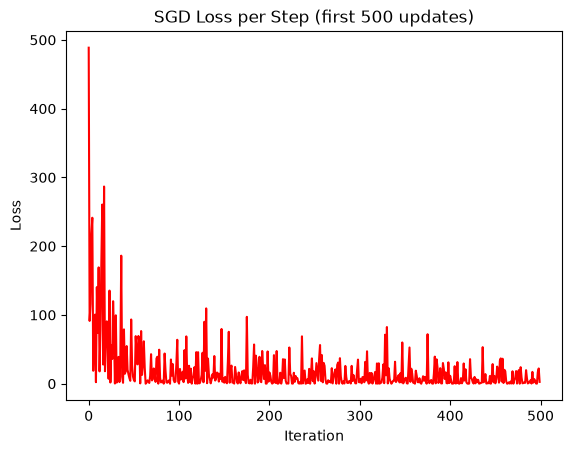

In [416]:
sgd_theta, losses = stochastic_gradient_descent(X_b, y)
# In loss cho 500 bước đầu
x_axis = list(range(500))
plt.plot(x_axis, losses[:500], color="r")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("SGD Loss per Step (first 500 updates)")
plt.show()